# Linear Algebra in AI: MovieLens Companion Notebook

This notebook supports the article on linear algebra in AI. It uses the MovieLens dataset to demonstrate user–movie matrices, mean-centering, cosine similarity, SVD movie embeddings, and a lightweight context-based recommender.

The goal is interpretability, not production recommendation performance.

In [3]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.sparse import csr_matrix
from sklearn.decomposition import TruncatedSVD

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

DATA_DIR = Path("ml-32m")

required_files = ["movies.csv", "ratings.csv"]
missing_files = [filename for filename in required_files if not (DATA_DIR / filename).exists()]

if missing_files:
    raise FileNotFoundError(
        "Missing MovieLens files: "
        + ", ".join(missing_files)
        + f"\nExpected them under: {DATA_DIR.resolve()}"
    )


## 1. Load Data

The article only needs movie metadata and ratings. `links.csv` and `tags.csv` are part of MovieLens, but they are not used in this walkthrough.

The notebook expects the MovieLens files to be available in the `ml-32m` directory.

In [4]:
movies_df = pd.read_csv(DATA_DIR / "movies.csv")
ratings_df = pd.read_csv(DATA_DIR / "ratings.csv")

print("Movies:", movies_df.shape)
print("Ratings:", ratings_df.shape)

display(movies_df.head())
display(ratings_df.head())


Movies: (87585, 3)
Ratings: (32000204, 4)


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


,userId,movieId,rating,timestamp
0,1,17,4.0,944249077
1,1,25,1.0,944250228
2,1,29,2.0,943230976
3,1,30,5.0,944249077
4,1,32,5.0,943228858


## 2. Build a Sparse User–Movie Matrix

Rows represent users, columns represent movies, and stored values represent observed ratings. A sparse matrix is used because most possible user–movie combinations are not observed.

In [5]:
MIN_BASE_USER_RATINGS = 20
MIN_BASE_MOVIE_RATINGS = 50

base_ratings = ratings_df.copy()

# Keep users and movies with enough observations for stable examples.
user_counts = base_ratings.groupby("userId").size()
good_users = user_counts[user_counts >= MIN_BASE_USER_RATINGS].index
base_ratings = base_ratings[base_ratings["userId"].isin(good_users)]

movie_counts = base_ratings.groupby("movieId").size()
good_movies = movie_counts[movie_counts >= MIN_BASE_MOVIE_RATINGS].index
base_ratings = base_ratings[base_ratings["movieId"].isin(good_movies)].reset_index(drop=True)

base_user_ids = base_ratings["userId"].drop_duplicates().to_numpy()
base_movie_ids = base_ratings["movieId"].drop_duplicates().to_numpy()

base_user_to_idx = {user_id: i for i, user_id in enumerate(base_user_ids)}
base_movie_to_idx = {movie_id: i for i, movie_id in enumerate(base_movie_ids)}
base_idx_to_movie_id = {i: movie_id for movie_id, i in base_movie_to_idx.items()}

base_ratings["u_idx"] = base_ratings["userId"].map(base_user_to_idx).astype(np.int32)
base_ratings["m_idx"] = base_ratings["movieId"].map(base_movie_to_idx).astype(np.int32)

R_sparse = csr_matrix(
    (
        base_ratings["rating"].to_numpy(dtype=np.float32),
        (base_ratings["u_idx"].to_numpy(), base_ratings["m_idx"].to_numpy()),
    ),
    shape=(len(base_user_ids), len(base_movie_ids)),
    dtype=np.float32,
)

print(f"Users: {R_sparse.shape[0]:,}")
print(f"Movies: {R_sparse.shape[1]:,}")
print(f"Observed ratings: {R_sparse.nnz:,}")
print(f"Sparsity: {1 - (R_sparse.nnz / (R_sparse.shape[0] * R_sparse.shape[1])):.2%}")

Users: 200,947
Movies: 16,034
Observed ratings: 31,498,689
Sparsity: 99.02%


## 3. Display a Small Slice of the Matrix

This displays the edges of the sparse matrix so the scale is visible without printing thousands of rows or columns.

In [6]:
# Display sparse user–movie matrix sample: top/bottom users × left/right movies.
k = 5
n_users, n_movies = R_sparse.shape

movie_title_lookup = (
    movies_df[["movieId", "title"]]
    .drop_duplicates()
    .set_index("movieId")["title"]
)

top_user_idx = np.arange(k)
bottom_user_idx = np.arange(n_users - k, n_users)
selected_user_idx = np.concatenate([top_user_idx, bottom_user_idx])

left_movie_idx = np.arange(k)
right_movie_idx = np.arange(n_movies - k, n_movies)
selected_movie_idx = np.concatenate([left_movie_idx, right_movie_idx])

R_sample = R_sparse[selected_user_idx, :][:, selected_movie_idx].toarray()

selected_movie_ids = base_movie_ids[selected_movie_idx]
selected_movie_titles = movie_title_lookup.reindex(selected_movie_ids).fillna(
    pd.Series(selected_movie_ids, index=selected_movie_ids).astype(str)
)

pivot_sample = pd.DataFrame(
    R_sample,
    index=[f"User {i+1}" for i in selected_user_idx],
    columns=selected_movie_titles.values,
).round(1).replace(0, "")

row_ellipsis = pd.DataFrame(
    [["..."] * pivot_sample.shape[1]],
    columns=pivot_sample.columns,
    index=["..."],
)

pivot_rows = pd.concat([
    pivot_sample.iloc[:k],
    row_ellipsis,
    pivot_sample.iloc[k:],
])

left_cols = pivot_rows.iloc[:, :k]
right_cols = pivot_rows.iloc[:, -k:]

col_ellipsis = pd.DataFrame(
    [["..."] for _ in range(pivot_rows.shape[0])],
    index=pivot_rows.index,
    columns=["..."],
)

pivot_final = pd.concat([left_cols, col_ellipsis, right_cols], axis=1)
pivot_final.index.name = f"Users ({n_users:,} total)"
pivot_final.columns.name = f"Movies ({n_movies:,} total)"

print(f"User–Movie Matrix ({n_users:,} users × {n_movies:,} movies)")
pivot_final

User–Movie Matrix (200,947 users × 16,034 movies)


"Movies (16,034 total)",Sense and Sensibility (1995),Leaving Las Vegas (1995),"City of Lost Children, The (Cité des enfants perdus, La) (1995)",Shanghai Triad (Yao a yao yao dao waipo qiao) (1995),Twelve Monkeys (a.k.a. 12 Monkeys) (1995),...,JLG/JLG (JLG/JLG - autoportrait de décembre) (1994),Barbie: Mariposa and The Fairy Princess (2013),Into Great Silence (Die große Stille) (2005),Cloak and Dagger (1946),Johnny Express (2014)
"Users (200,947 total)",,,,,,,,,,,
User 1,4.0,1.0,2.0,5.0,5.0,...,,,,,
User 2,,,,,,...,,,,,
User 3,5.0,,,,,...,,,,,
User 4,,,,,,...,,,,,
User 5,,,,,,...,,,,,
...,...,...,...,...,...,...,...,...,...,...,...
User 200943,,,,,,...,,,,,
User 200944,,,,,5.0,...,,,,,
User 200945,4.0,3.0,,,,...,,,,,


## 4. Simple User Vector Example

This produces the small table used to introduce the idea of a user rating vector.

In [7]:
# Select five popular movies and five users who rated all of them.
top_5_movie_idx = (
    base_ratings.groupby("m_idx").size()
    .sort_values(ascending=False)
    .head(5)
    .index
)

ratings_top5 = base_ratings[base_ratings["m_idx"].isin(top_5_movie_idx)]
valid_users = (
    ratings_top5.groupby("userId")["m_idx"]
    .nunique()
    .loc[lambda s: s == 5]
    .index
)

selected_users = list(valid_users[:5])

user_movie_table = (
    ratings_top5[ratings_top5["userId"].isin(selected_users)]
    .pivot(index="userId", columns="m_idx", values="rating")
)

movie_titles_by_midx = pd.Series(
    {idx: movie_title_lookup.get(movie_id, str(movie_id)) for idx, movie_id in base_idx_to_movie_id.items()}
)
user_movie_table.columns = movie_titles_by_midx.loc[user_movie_table.columns].values
user_movie_table.index = [f"User {chr(65+i)}" for i in range(len(user_movie_table))]
user_movie_table = user_movie_table.round(1)

user_a_vector = user_movie_table.loc[["User A"]].T
user_a_vector.columns = ["Rating"]

display(user_a_vector)
display(user_movie_table)

,Rating
Forrest Gump (1994),3.5
"Silence of the Lambs, The (1991)",5.0
Pulp Fiction (1994),4.5
"Shawshank Redemption, The (1994)",4.0
"Matrix, The (1999)",4.0


,Forrest Gump (1994),"Silence of the Lambs, The (1991)",Pulp Fiction (1994),"Shawshank Redemption, The (1994)","Matrix, The (1999)"
User A,3.5,5.0,4.5,4.0,4.0
User B,5.0,4.0,2.0,5.0,2.0
User C,2.0,5.0,5.0,5.0,4.5
User D,5.0,4.0,5.0,5.0,5.0
User E,4.5,4.0,5.0,5.0,5.0


## 5. Cosine Similarity on Mean-Centered Ratings

This section computes pairwise movie similarity for the 100 most popular movies. Ratings are mean-centered by user before similarity is computed, so each value represents relative preference rather than a raw score.

In [8]:
TOP_N_SIMILARITY_MOVIES = 100
MIN_OVERLAP = 10

popular_movie_idx = (
    base_ratings.groupby("m_idx").size()
    .sort_values(ascending=False)
    .head(TOP_N_SIMILARITY_MOVIES)
    .index
)

similarity_ratings = base_ratings[base_ratings["m_idx"].isin(popular_movie_idx)].copy()

R_similarity = similarity_ratings.pivot_table(
    index="userId",
    columns="m_idx",
    values="rating",
)

R_similarity_centered = R_similarity.sub(R_similarity.mean(axis=1), axis=0)


def cosine_overlap(a, b, min_overlap=MIN_OVERLAP):
    """Cosine similarity using only users who rated both movies."""
    mask = (~np.isnan(a)) & (~np.isnan(b))
    if mask.sum() < min_overlap:
        return np.nan

    x = a[mask]
    y = b[mask]
    return np.dot(x, y) / (np.linalg.norm(x) * np.linalg.norm(y) + 1e-8)

movie_indices = R_similarity_centered.columns.tolist()
n = len(movie_indices)
similarity_matrix = np.full((n, n), np.nan, dtype=np.float32)

for i, movie_i in enumerate(movie_indices):
    for j, movie_j in enumerate(movie_indices):
        if i == j:
            similarity_matrix[i, j] = 1.0
        elif i < j:
            value = cosine_overlap(
                R_similarity_centered[movie_i].values,
                R_similarity_centered[movie_j].values,
            )
            similarity_matrix[i, j] = value
            similarity_matrix[j, i] = value

similarity_titles = movie_titles_by_midx.loc[movie_indices].values
sim_df = pd.DataFrame(similarity_matrix, index=similarity_titles, columns=similarity_titles).round(2)

sim_df

,Twelve Monkeys (a.k.a. 12 Monkeys) (1995),Babe (1995),Braveheart (1995),Taxi Driver (1976),Star Wars: Episode IV - A New Hope (1977),Forrest Gump (1994),Schindler's List (1993),Blade Runner (1982),"Silence of the Lambs, The (1991)",Fargo (1996),...,Batman Begins (2005),Iron Man (2008),WALL·E (2008),Up (2009),Good Will Hunting (1997),"Green Mile, The (1999)",Groundhog Day (1993),Interstellar (2014),One Flew Over the Cuckoo's Nest (1975),"Incredibles, The (2004)"
Twelve Monkeys (a.k.a. 12 Monkeys) (1995),1.00,-0.09,-0.07,0.13,-0.09,-0.10,-0.01,0.20,0.05,0.11,...,-0.06,-0.12,-0.01,-0.04,-0.00,-0.05,0.08,0.02,0.11,-0.08
Babe (1995),-0.09,1.00,-0.08,-0.06,-0.14,-0.12,-0.06,-0.08,-0.13,0.01,...,-0.10,0.01,-0.07,-0.01,-0.14,-0.13,0.03,-0.16,-0.15,0.08
Braveheart (1995),-0.07,-0.08,1.00,-0.14,-0.04,0.16,0.11,-0.15,0.04,-0.16,...,0.01,0.01,-0.10,-0.09,0.09,0.09,-0.10,-0.02,-0.11,-0.07
Taxi Driver (1976),0.13,-0.06,-0.14,1.00,-0.03,-0.15,0.08,0.28,0.19,0.35,...,-0.13,-0.20,-0.04,-0.06,-0.06,-0.12,0.03,-0.07,0.35,-0.14
Star Wars: Episode IV - A New Hope (1977),-0.09,-0.14,-0.04,-0.03,1.00,-0.10,0.02,0.11,-0.02,-0.03,...,-0.00,-0.03,-0.06,-0.09,-0.10,-0.16,-0.06,-0.11,-0.02,-0.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"Green Mile, The (1999)",-0.05,-0.13,0.09,-0.12,-0.16,0.27,0.13,-0.15,0.05,-0.10,...,-0.08,-0.08,-0.01,0.01,0.15,1.00,-0.07,0.05,0.02,-0.11
Groundhog Day (1993),0.08,0.03,-0.10,0.03,-0.06,-0.04,-0.06,0.06,-0.06,0.08,...,-0.08,-0.10,0.01,-0.03,-0.03,-0.07,1.00,-0.07,0.05,0.00
Interstellar (2014),0.02,-0.16,-0.02,-0.07,-0.11,0.06,0.02,-0.03,-0.04,-0.07,...,0.05,-0.04,0.01,-0.05,0.08,0.05,-0.07,1.00,-0.05,-0.14
One Flew Over the Cuckoo's Nest (1975),0.11,-0.15,-0.11,0.35,-0.02,0.01,0.23,0.20,0.23,0.29,...,-0.14,-0.25,-0.03,-0.04,0.06,0.02,0.05,-0.05,1.00,-0.12


In [9]:
target_title = "Lord of the Rings: The Fellowship of the Ring, The (2001)"

sims = sim_df.loc[target_title].drop(target_title)
top_5 = sims.sort_values(ascending=False).head(5)
bottom_5 = sims.sort_values(ascending=True).head(5)


def format_similarity_list(series, heading):
    lines = [f"**{heading}**\n"]
    for name, value in series.items():
        lines.append(f"- {name} — {value:.2f}")
    return "\n".join(lines)


print(
    "\n\n".join([
        format_similarity_list(top_5, "Top 5 most similar to Fellowship of the Ring"),
        format_similarity_list(bottom_5, "Bottom 5 least similar to Fellowship of the Ring"),
    ])
)

**Top 5 most similar to Fellowship of the Ring**

- Lord of the Rings: The Return of the King, The (2003) — 0.86
- Lord of the Rings: The Two Towers, The (2002) — 0.85
- Star Wars: Episode V - The Empire Strikes Back (1980) — 0.18
- Star Wars: Episode IV - A New Hope (1977) — 0.16
- Star Wars: Episode VI - Return of the Jedi (1983) — 0.13

**Bottom 5 least similar to Fellowship of the Ring**

- Mask, The (1994) — -0.31
- Mrs. Doubtfire (1993) — -0.28
- Speed (1994) — -0.27
- Dumb & Dumber (Dumb and Dumber) (1994) — -0.27
- Ace Ventura: Pet Detective (1994) — -0.27


## 6. Visualize Similarity Structure

This projects the movie similarity matrix into two dimensions so we can inspect whether local clusters emerge.

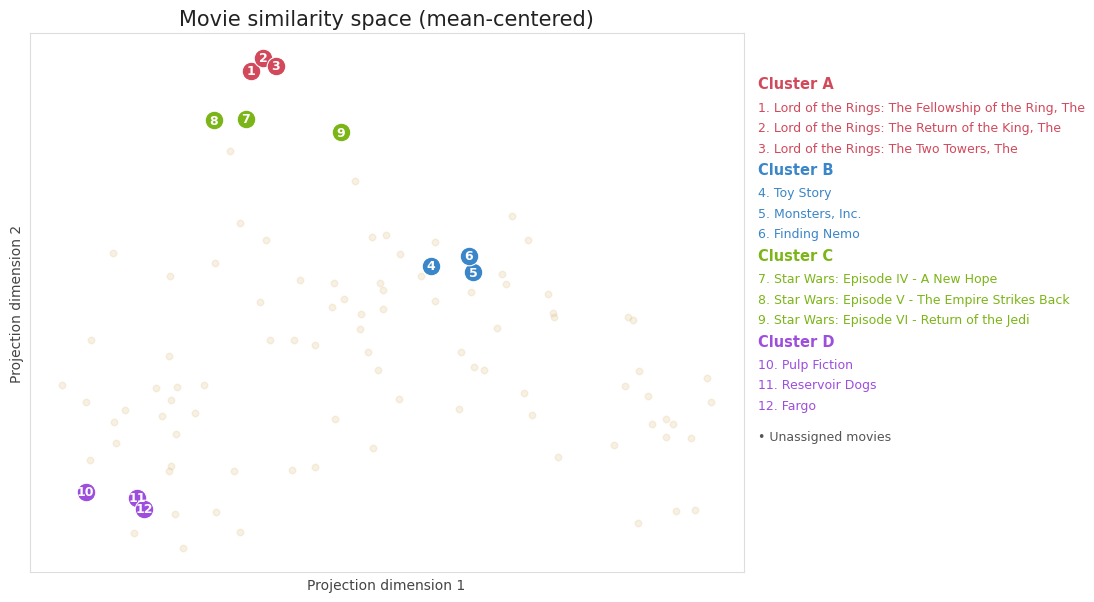

In [10]:
anchors = [
    "Lord of the Rings: The Fellowship of the Ring, The (2001)",
    "Toy Story (1995)",
    "Star Wars: Episode IV - A New Hope (1977)",
    "Pulp Fiction (1994)",
]

clusters = {}
for anchor in anchors:
    sims = sim_df.loc[anchor].drop(anchor)
    top_similar = sims.sort_values(ascending=False).head(2).index.tolist()
    clusters[anchor] = [anchor] + top_similar

projection = TruncatedSVD(n_components=2, random_state=RANDOM_SEED)
movie_2d = projection.fit_transform(np.nan_to_num(sim_df.values, nan=0.0))

movie_titles = sim_df.index.tolist()
title_to_idx = {title: i for i, title in enumerate(movie_titles)}

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

ax.scatter(
    movie_2d[:, 0],
    movie_2d[:, 1],
    s=22,
    alpha=0.18,
    color="#d8b26a",
    label="Unassigned movies",
)

colors = ["#d1495b", "#3a86c8", "#7cb518", "#9d4edd"]
cluster_names = ["Cluster A", "Cluster B", "Cluster C", "Cluster D"]

label_counter = 1
legend_rows = []

for cluster_id, (anchor, cluster_movies) in enumerate(clusters.items()):
    color = colors[cluster_id]
    legend_rows.append((cluster_names[cluster_id], color, None))

    for movie in cluster_movies:
        idx = title_to_idx.get(movie)
        if idx is None:
            continue

        x, y = movie_2d[idx]
        ax.scatter(x, y, s=180, color=color, edgecolor="white", linewidth=0.8, zorder=3)
        ax.text(x, y, str(label_counter), fontsize=9, ha="center", va="center", color="white", weight="bold", zorder=4)
        legend_rows.append((f"{label_counter}. {movie.split(' (')[0]}", color, label_counter))
        label_counter += 1

ax.set_title("Movie similarity space (mean-centered)", fontsize=15, color="#222222")
ax.set_xlabel("Projection dimension 1", color="#444444")
ax.set_ylabel("Projection dimension 2", color="#444444")
ax.set_xticks([])
ax.set_yticks([])

for spine in ax.spines.values():
    spine.set_color("#dddddd")

# Lightweight legend panel to the right.
y = 0.92
x = 1.02
for text, color, _ in legend_rows:
    is_header = text.startswith("Cluster")
    ax.text(
        x,
        y,
        text,
        transform=ax.transAxes,
        color=color,
        fontsize=10.5 if is_header else 9,
        weight="bold" if is_header else "normal",
        ha="left",
        va="top",
    )
    y -= 0.045 if is_header else 0.038
    if text.endswith("Goodfellas"):
        y -= 0.015

ax.scatter([], [], s=40, color="#d8b26a", alpha=0.4, label="Unassigned movies")
ax.text(x, y - 0.02, "• Unassigned movies", transform=ax.transAxes, color="#555555", fontsize=9, ha="left", va="top")

plt.subplots_adjust(right=0.72)
plt.show()

## 7. SVD Movie Embeddings

For the context-based recommender, we first compress the sparse user–movie matrix into dense movie vectors. SVD gives us the movie embeddings; cosine similarity is still used later to compare those embeddings.

In [11]:
RECOMMENDER_MAX_USERS = 20_000
TOP_N_RECOMMENDER_MOVIES = 1_000
MIN_RECOMMENDER_USER_RATINGS = 20
LATENT_DIM = 32

unique_users = base_ratings["userId"].drop_duplicates().to_numpy()
sample_size = min(RECOMMENDER_MAX_USERS, len(unique_users))
sampled_users = np.random.choice(unique_users, size=sample_size, replace=False)

rec_ratings = base_ratings[base_ratings["userId"].isin(sampled_users)].copy()
rec_ratings = rec_ratings[["userId", "movieId", "rating", "timestamp"]].copy()

rec_ratings["userId"] = pd.to_numeric(rec_ratings["userId"], downcast="integer")
rec_ratings["movieId"] = pd.to_numeric(rec_ratings["movieId"], downcast="integer")
rec_ratings["rating"] = pd.to_numeric(rec_ratings["rating"], downcast="float")
rec_ratings["timestamp"] = pd.to_numeric(rec_ratings["timestamp"], downcast="integer")

popular_rec_movies = rec_ratings["movieId"].value_counts().head(TOP_N_RECOMMENDER_MOVIES).index
rec_ratings = rec_ratings[rec_ratings["movieId"].isin(popular_rec_movies)].reset_index(drop=True)

rec_user_counts = rec_ratings["userId"].value_counts()
keep_rec_users = rec_user_counts[rec_user_counts >= MIN_RECOMMENDER_USER_RATINGS].index
rec_ratings = rec_ratings[rec_ratings["userId"].isin(keep_rec_users)].reset_index(drop=True)

rec_user_ids = rec_ratings["userId"].drop_duplicates().to_numpy()
rec_movie_ids = rec_ratings["movieId"].drop_duplicates().to_numpy()

rec_user_to_idx = {user_id: i for i, user_id in enumerate(rec_user_ids)}
rec_movie_to_idx = {movie_id: i for i, movie_id in enumerate(rec_movie_ids)}

rec_ratings["u_idx"] = rec_ratings["userId"].map(rec_user_to_idx).astype(np.int32)
rec_ratings["m_idx"] = rec_ratings["movieId"].map(rec_movie_to_idx).astype(np.int32)

R_rec_sparse = csr_matrix(
    (
        rec_ratings["rating"].to_numpy(dtype=np.float32),
        (rec_ratings["u_idx"].to_numpy(), rec_ratings["m_idx"].to_numpy()),
    ),
    shape=(len(rec_user_ids), len(rec_movie_ids)),
    dtype=np.float32,
)

print(f"Recommender matrix: {R_rec_sparse.shape[0]:,} users × {R_rec_sparse.shape[1]:,} movies")
print(f"Observed ratings: {R_rec_sparse.nnz:,}")
print(f"Sparsity: {1 - (R_rec_sparse.nnz / (R_rec_sparse.shape[0] * R_rec_sparse.shape[1])):.2%}")

Recommender matrix: 17,911 users × 1,000 movies
Observed ratings: 1,840,202
Sparsity: 89.73%


In [12]:
# User mean-centering converts raw ratings into relative preference before SVD.
user_sum = np.array(R_rec_sparse.sum(axis=1)).ravel()
user_n = np.diff(R_rec_sparse.indptr)
user_mean = np.divide(user_sum, user_n, out=np.zeros_like(user_sum), where=user_n != 0)

R_rec_centered = R_rec_sparse.copy()
row_idx = np.repeat(np.arange(R_rec_centered.shape[0]), np.diff(R_rec_centered.indptr))
R_rec_centered.data = R_rec_centered.data - user_mean[row_idx]

svd = TruncatedSVD(n_components=LATENT_DIM, random_state=RANDOM_SEED)
movie_embeddings = svd.fit_transform(R_rec_centered.T).astype(np.float32)

print("Movie embedding shape:", movie_embeddings.shape)
print(f"Explained variance ratio: {svd.explained_variance_ratio_.sum():.2%}")

Movie embedding shape: (1000, 32)
Explained variance ratio: 22.92%


## 8. Context-Based Ranking Functions

The ranking function turns a user's recent rating history into a candidate-specific context vector.

For each candidate movie, it:

1. compares the candidate embedding to each movie in the user's history,
2. combines similarity with local mean-centered rating,
3. converts those relevance scores into attention-style weights,
4. builds a weighted context vector, and
5. scores the candidate against that context vector.

In [13]:
SOFTMAX_TEMPERATURE = 0.30

movie_lookup = movies_df[["movieId", "title"]].drop_duplicates()


def cosine_sim(query_vector, matrix, eps=1e-8):
    """Cosine similarity between one query vector and each row in a matrix."""
    query_norm = np.linalg.norm(query_vector) + eps
    matrix_norms = np.linalg.norm(matrix, axis=1) + eps

    return (matrix @ query_vector) / (matrix_norms * query_norm)


def softmax(x, temperature=SOFTMAX_TEMPERATURE):
    """
    Convert raw relevance scores into attention-style weights.

    Lower temperature sharpens the distribution.
    Higher temperature spreads weight more evenly.
    """
    x = np.asarray(x, dtype=np.float32) / temperature
    x = x - np.max(x)

    exp_x = np.exp(x)

    return exp_x / (exp_x.sum() + 1e-8)


def add_local_preference(history_df):
    """
    Add local preference columns for a specific context window.

    local_mean_centered_rating is signed:
    - positive = rated above the window average
    - negative = rated below the window average
    """
    history_df = history_df.copy()

    history_df["local_mean_rating"] = history_df["rating"].mean()
    history_df["local_mean_centered_rating"] = (
        history_df["rating"] - history_df["local_mean_rating"]
    )

    return history_df


def build_history_vectors(
    history_df,
    movie_to_idx=rec_movie_to_idx,
    embeddings=movie_embeddings,
):
    """Convert watched movie IDs into embedding vectors, aligned with ratings."""
    valid_history = history_df[history_df["movieId"].isin(movie_to_idx)].copy()

    history_movie_ids = valid_history["movieId"].to_numpy()

    indices = np.array(
        [movie_to_idx[movie_id] for movie_id in history_movie_ids],
        dtype=np.int32,
    )

    history_vectors = embeddings[indices]
    ratings = valid_history["rating"].to_numpy(dtype=np.float32)

    return history_movie_ids, history_vectors, ratings


def rank_from_history(
    history_df,
    movie_ids=rec_movie_ids,
    movie_to_idx=rec_movie_to_idx,
    embeddings=movie_embeddings,
    movie_lookup=movie_lookup,
    temperature=SOFTMAX_TEMPERATURE,
):
    """
    Rank candidate movies using the article's attention-style mechanism.

    For each candidate:
    - compare it to movies in the user's history,
    - combine similarity with local mean-centered rating,
    - convert relevance scores into softmax weights,
    - build a candidate-specific context vector,
    - score the candidate against that context vector.

    Below-average ratings can reduce relevance before softmax.
    After softmax, all weights are positive, so weaker matches receive
    less influence rather than becoming active negative vectors.
    """
    history_movie_ids, history_vectors, ratings = build_history_vectors(
        history_df=history_df,
        movie_to_idx=movie_to_idx,
        embeddings=embeddings,
    )

    watched = set(history_movie_ids)

    local_mean_rating = ratings.mean()
    preference = ratings - local_mean_rating

    scores = []

    for i, movie_id in enumerate(movie_ids):
        if movie_id in watched:
            continue

        candidate_vector = embeddings[i]

        # Candidate-to-history similarity.
        similarities = cosine_sim(candidate_vector, history_vectors)

        # Attention-style relevance:
        # similar + rated above local average -> higher relevance
        # similar + rated below local average -> lower relevance
        relevance = similarities * preference

        weights = softmax(relevance, temperature=temperature)
        context_vector = weights @ history_vectors

        score = cosine_sim(
            candidate_vector,
            context_vector.reshape(1, -1),
        )[0]

        scores.append((movie_id, score))

    results = pd.DataFrame(scores, columns=["movieId", "score"])
    results = results.merge(movie_lookup, on="movieId", how="left")

    return results.sort_values("score", ascending=False).reset_index(drop=True)


## 9. Example: First 10 vs Next 10 Movies

We use one target user and compare recommendations from two different snapshots of their history.

In [14]:
rec_user_counts = rec_ratings.groupby("userId").size()
candidate_users = rec_user_counts[(rec_user_counts >= 30) & (rec_user_counts <= 150)].index

target_user = candidate_users[3] if len(candidate_users) > 3 else candidate_users[0]

user_history = (
    rec_ratings[rec_ratings["userId"] == target_user]
    .sort_values("timestamp")
    .merge(movie_lookup, on="movieId", how="left")
    .reset_index(drop=True)
)

first_10 = add_local_preference(user_history.iloc[:10])
next_10 = add_local_preference(user_history.iloc[10:20])

print("Target user:", target_user)
print("Number of ratings:", rec_user_counts[target_user])
print("First 10 mean rating:", first_10["rating"].mean().round(2))
print("Next 10 mean rating:", next_10["rating"].mean().round(2))

print("\nFirst 10 movies:")
display(first_10[["title", "rating", "local_mean_centered_rating"]])

print("\nNext 10 movies:")
display(next_10[["title", "rating", "local_mean_centered_rating"]])

Target user: 23
Number of ratings: 38
First 10 mean rating: 3.75
Next 10 mean rating: 4.4

First 10 movies:


,title,rating,local_mean_centered_rating
0,"Shawshank Redemption, The (1994)",5.0,1.25
1,Star Wars: Episode V - The Empire Strikes Back...,3.0,-0.75
2,Star Wars: Episode IV - A New Hope (1977),3.0,-0.75
3,"Matrix, The (1999)",3.5,-0.25
4,Logan (2017),3.0,-0.75
5,Avengers: Infinity War - Part II (2019),4.0,0.25
6,Forrest Gump (1994),4.0,0.25
7,Pulp Fiction (1994),4.0,0.25
8,Toy Story (1995),3.0,-0.75
9,Inception (2010),5.0,1.25



Next 10 movies:


,title,rating,local_mean_centered_rating
10,Good Will Hunting (1997),4.0,-0.4
11,Interstellar (2014),5.0,0.6
12,"Dark Knight, The (2008)",4.0,-0.4
13,Iron Man (2008),5.0,0.6
14,Edge of Tomorrow (2014),5.0,0.6
15,Guardians of the Galaxy (2014),3.5,-0.9
16,The Imitation Game (2014),5.0,0.6
17,"Dark Knight Rises, The (2012)",4.0,-0.4
18,Deadpool (2016),4.0,-0.4
19,Avatar (2009),4.5,0.1


In [28]:
results_first = rank_from_history(first_10)
results_next = rank_from_history(next_10)

print("Top recommendations from first 10 movies:")
display(results_first.head(10)[["title", "score"]])

print("Top recommendations from next 10 movies:")
display(results_next.head(10)[["title", "score"]])

Top recommendations from first 10 movies:


,title,score
0,"Prestige, The (2006)",0.892219
1,Interstellar (2014),0.874177
2,"Dark Knight, The (2008)",0.754842
3,Shutter Island (2010),0.708327
4,Gone Girl (2014),0.691014
5,Catch Me If You Can (2002),0.684868
6,"Departed, The (2006)",0.672750
7,"Usual Suspects, The (1995)",0.671328
8,Inside Man (2006),0.667616
9,"Dark Knight Rises, The (2012)",0.656263


Top recommendations from next 10 movies:


,title,score
0,The Martian (2015),0.909420
1,Inception (2010),0.885552
2,Star Trek (2009),0.871597
3,"Avengers, The (2012)",0.780115
4,"Prestige, The (2006)",0.768007
5,Avengers: Infinity War - Part I (2018),0.743512
6,About Time (2013),0.739948
7,X-Men: First Class (2011),0.726840
8,Avengers: Infinity War - Part II (2019),0.724185
9,Inside Man (2006),0.722439


## 10. Inspect Candidate Attention Weights

This diagnostic table shows which history movies shape the context vector for a specific candidate movie.

The weights are useful for interpretation: they show which past ratings the model leaned on when scoring a recommendation.

In [17]:
def inspect_candidate_attention(
    candidate_title,
    history_df,
    movie_lookup=movie_lookup,
    movie_to_idx=rec_movie_to_idx,
    embeddings=movie_embeddings,
    temperature=SOFTMAX_TEMPERATURE,
):
    """
    Inspect the attention-style weights for one candidate movie.

    The table shows the full path from history movie to final weight:
    local preference, candidate similarity, relevance, and softmax weight.
    """
    candidate_row = movie_lookup[movie_lookup["title"] == candidate_title]

    if candidate_row.empty:
        raise ValueError(f"Candidate title not found: {candidate_title}")

    candidate_movie_id = candidate_row["movieId"].iloc[0]

    if candidate_movie_id not in movie_to_idx:
        raise ValueError(f"Candidate not present in filtered movie set: {candidate_title}")

    candidate_vector = embeddings[movie_to_idx[candidate_movie_id]]

    history_movie_ids, history_vectors, ratings = build_history_vectors(
        history_df,
        movie_to_idx,
        embeddings,
    )

    local_mean_rating = ratings.mean()
    local_preference = ratings - local_mean_rating

    similarities = cosine_sim(candidate_vector, history_vectors)

    # Signed relevance before softmax.
    relevance = similarities * local_preference

    # Softmax converts relevance scores into positive weights.
    weights = softmax(relevance, temperature=temperature)

    attention_df = pd.DataFrame({
        "movieId": history_movie_ids,
        "rating": ratings,
        "local_mean_rating": local_mean_rating,
        "local_mean_centered_rating": local_preference,
        "similarity_to_candidate": similarities,
        "relevance": relevance,
        "attention_weight": weights,
    })

    attention_df = attention_df.merge(movie_lookup, on="movieId", how="left")

    ordered_columns = [
        "title",
        "rating",
        "local_mean_centered_rating",
        "similarity_to_candidate",
        "relevance",
        "attention_weight",
    ]

    return (
        attention_df[ordered_columns]
        .sort_values("attention_weight", ascending=False)
        .reset_index(drop=True)
    )


# Example diagnostic: inspect which history movies shaped the top recommendation.
example_candidate = results_first.iloc[0]["title"]

print("Candidate:", example_candidate)
display(inspect_candidate_attention(example_candidate, first_10).head(10))


Candidate: Prestige, The (2006)


,title,rating,local_mean_centered_rating,similarity_to_candidate,relevance,attention_weight
0,Inception (2010),5.0,1.25,0.902116,1.127645,0.774952
1,"Shawshank Redemption, The (1994)",5.0,1.25,0.413508,0.516885,0.101183
2,Pulp Fiction (1994),4.0,0.25,0.177699,0.044425,0.020948
3,Forrest Gump (1994),4.0,0.25,0.154105,0.038526,0.020541
4,Avengers: Infinity War - Part II (2019),4.0,0.25,-0.000478,-0.000120,0.018058
5,Star Wars: Episode IV - A New Hope (1977),3.0,-0.75,0.039410,-0.029558,0.016370
6,Star Wars: Episode V - The Empire Strikes Back...,3.0,-0.75,0.105932,-0.079449,0.013862
7,"Matrix, The (1999)",3.5,-0.25,0.371471,-0.092868,0.013256
8,Toy Story (1995),3.0,-0.75,0.128385,-0.096289,0.013105
9,Logan (2017),3.0,-0.75,0.339861,-0.254896,0.007724


## 11. Full-Catalog Retrieval Validation

The recommendation examples are useful qualitatively, but the model also needs a simple quantitative check.

This validation removes a small number of liked movies from each user's history, keeps most of the user's ratings as context, and asks whether the recommender can retrieve those held-out liked movies from the full catalog.

The comparison is against three simple baselines:

- global movie average,
- movie popularity,
- random ranking.

In [18]:
EPS = 1e-8
rng = np.random.default_rng(RANDOM_SEED)

# Conservative validation settings.
# These keep most of each user's ratings available as context.
MIN_CONTEXT_RATINGS = 20
MAX_HELDOUT_LIKED_MOVIES = 3
MAX_TEST_FRACTION = 0.10
MIN_HELDOUT_LIKED_MOVIES = 1
MIN_LIKED_RATING = 4.0

K_VALUES = [20, 50, 100]

n_users = len(rec_user_ids)
n_movies = len(rec_movie_ids)

### 11.1 Create a Conservative Holdout Split

A liked movie is defined relative to both the rating scale and the user's own behavior:

```text
rating >= max(4.0, user's average rating)
```

The test set is deliberately small. This avoids removing too much of the user history, because the recommender needs that history to build meaningful context.

In [19]:
def create_liked_movie_retrieval_split(
    ratings,
    min_context_ratings=MIN_CONTEXT_RATINGS,
    max_heldout_liked_movies=MAX_HELDOUT_LIKED_MOVIES,
    max_test_fraction=MAX_TEST_FRACTION,
    min_heldout_liked_movies=MIN_HELDOUT_LIKED_MOVIES,
    min_liked_rating=MIN_LIKED_RATING,
):
    """
    Split each user's ratings into:
    - training context: most ratings, used to build recommendations
    - held-out liked movies: a small target set to recover

    Holdout size is capped by:
    - absolute maximum, e.g. 3 movies,
    - fraction of available ratings, e.g. 10%,
    - requirement that at least min_context_ratings remain.
    """
    train_parts = []
    test_parts = []

    for user_id, user_df in ratings.groupby("userId", sort=False):
        user_df = user_df.sort_values("timestamp").copy()

        user_mean = user_df["rating"].mean()
        liked_cutoff = max(min_liked_rating, user_mean)

        liked_df = user_df[user_df["rating"] >= liked_cutoff]

        max_by_fraction = max(
            1,
            int(np.floor(len(user_df) * max_test_fraction)),
        )

        max_by_context = len(user_df) - min_context_ratings

        n_holdout = min(
            max_heldout_liked_movies,
            max_by_fraction,
            len(liked_df),
            max_by_context,
        )

        if n_holdout < min_heldout_liked_movies:
            train_parts.append(user_df)
            continue

        heldout_idx = rng.choice(
            liked_df.index.to_numpy(),
            size=n_holdout,
            replace=False,
        )

        test_parts.append(user_df.loc[heldout_idx])
        train_parts.append(user_df.drop(index=heldout_idx))

    train_ratings = pd.concat(train_parts, ignore_index=True)

    if len(test_parts) == 0:
        test_ratings = pd.DataFrame(columns=ratings.columns)
    else:
        test_ratings = pd.concat(test_parts, ignore_index=True)

    return train_ratings, test_ratings


retrieval_train_ratings, retrieval_test_ratings = create_liked_movie_retrieval_split(
    rec_ratings
)

print(f"Train ratings: {len(retrieval_train_ratings):,}")
print(f"Held-out liked ratings: {len(retrieval_test_ratings):,}")
print(f"Evaluation users: {retrieval_test_ratings['userId'].nunique():,}")

if len(retrieval_test_ratings) > 0:
    heldout_per_user = retrieval_test_ratings.groupby("userId").size()

    print(f"Average held-out liked movies per user: {heldout_per_user.mean():.2f}")
    print(f"Median held-out liked movies per user: {heldout_per_user.median():.0f}")
    print(f"Max held-out liked movies for any user: {heldout_per_user.max():.0f}")

Train ratings: 1,791,114
Held-out liked ratings: 49,088
Evaluation users: 17,435
Average held-out liked movies per user: 2.82
Median held-out liked movies per user: 3
Max held-out liked movies for any user: 3


### 11.2 Refit SVD on the Training Data

The held-out ratings should not leak into the embedding step.

For validation, the movie embeddings are rebuilt from the training ratings only. This keeps the setup closer to a real retrieval test: the model has to recover held-out liked movies without using those ratings to create the embedding space.

In [20]:
R_train_sparse = csr_matrix(
    (
        retrieval_train_ratings["rating"].to_numpy(dtype=np.float32),
        (
            retrieval_train_ratings["u_idx"].to_numpy(dtype=np.int32),
            retrieval_train_ratings["m_idx"].to_numpy(dtype=np.int32),
        ),
    ),
    shape=(n_users, n_movies),
    dtype=np.float32,
)

train_user_sum = np.array(R_train_sparse.sum(axis=1)).ravel()
train_user_count = np.diff(R_train_sparse.indptr)

global_train_mean = retrieval_train_ratings["rating"].mean()

train_user_mean = np.divide(
    train_user_sum,
    train_user_count,
    out=np.full(n_users, global_train_mean, dtype=np.float32),
    where=train_user_count != 0,
)

R_train_centered = R_train_sparse.copy()

row_idx = np.repeat(
    np.arange(R_train_centered.shape[0]),
    np.diff(R_train_centered.indptr),
)

R_train_centered.data = (
    R_train_centered.data - train_user_mean[row_idx]
).astype(np.float32)

retrieval_svd = TruncatedSVD(
    n_components=LATENT_DIM,
    random_state=RANDOM_SEED,
)

retrieval_movie_embeddings = retrieval_svd.fit_transform(
    R_train_centered.T
).astype(np.float32)

print("Movie embedding shape:", retrieval_movie_embeddings.shape)
print(
    f"Explained variance ratio: "
    f"{retrieval_svd.explained_variance_ratio_.sum():.2%}"
)

Movie embedding shape: (1000, 32)
Explained variance ratio: 22.68%


### 11.3 Score the Full Catalog

For each user, every candidate movie receives a score from the attention-style recommender.

Movies already present in the user's training context are excluded later during evaluation, because the goal is to recommend unseen movies.

In [21]:
def normalize_rows(matrix, eps=EPS):
    """Normalize each row vector to unit length."""
    norms = np.linalg.norm(matrix, axis=1, keepdims=True)

    return np.divide(
        matrix,
        norms,
        out=np.zeros_like(matrix),
        where=norms > eps,
    )


def rowwise_cosine(a, b, eps=EPS):
    """Cosine similarity between corresponding rows of two matrices."""
    numerator = np.sum(a * b, axis=1)
    denominator = np.linalg.norm(a, axis=1) * np.linalg.norm(b, axis=1)

    return numerator / (denominator + eps)


def softmax_rows(x, temperature=SOFTMAX_TEMPERATURE, eps=EPS):
    """Row-wise softmax for candidate-by-history relevance scores."""
    x = x / temperature
    x = x - np.max(x, axis=1, keepdims=True)

    exp_x = np.exp(x)

    return exp_x / (exp_x.sum(axis=1, keepdims=True) + eps)


retrieval_movie_embeddings_norm = normalize_rows(retrieval_movie_embeddings)


# Baselines are computed from training data only.
global_average_scores = np.full(
    n_movies,
    global_train_mean,
    dtype=np.float32,
)

movie_mean_by_idx = retrieval_train_ratings.groupby("m_idx")["rating"].mean()

global_average_scores[movie_mean_by_idx.index.to_numpy()] = (
    movie_mean_by_idx.to_numpy(dtype=np.float32)
)

movie_popularity_scores = np.zeros(n_movies, dtype=np.float32)

movie_count_by_idx = retrieval_train_ratings.groupby("m_idx")["rating"].size()

movie_popularity_scores[movie_count_by_idx.index.to_numpy()] = np.log1p(
    movie_count_by_idx.to_numpy(dtype=np.float32)
)


def softmax_context_full_catalog_scores(user_train_df):
    """
    Score all movies for one user using the article's recommender.

    The function vectorizes scoring across the full movie catalog:
    - similarities has shape n_movies x user_history_length,
    - weights has the same shape,
    - context_vectors contains one candidate-specific context vector per movie.
    """
    history_m_idx = user_train_df["m_idx"].to_numpy(dtype=np.int32)
    ratings = user_train_df["rating"].to_numpy(dtype=np.float32)

    local_mean_rating = ratings.mean()
    preference = ratings - local_mean_rating

    history_vectors = retrieval_movie_embeddings[history_m_idx]
    history_vectors_norm = retrieval_movie_embeddings_norm[history_m_idx]

    similarities = retrieval_movie_embeddings_norm @ history_vectors_norm.T
    relevance = similarities * preference[None, :]

    weights = softmax_rows(
        relevance,
        temperature=SOFTMAX_TEMPERATURE,
    )

    context_vectors = weights @ history_vectors

    scores = rowwise_cosine(
        retrieval_movie_embeddings,
        context_vectors,
    )

    return scores.astype(np.float32)

### 11.4 Evaluate Held-Out Retrieval

The main article metric is `Recall@50`: the share of held-out liked movies that appear in the top 50 recommendations.

`HitRate@50` is also useful. It measures the share of users with at least one held-out liked movie in their top 50.

In [22]:
def evaluate_full_catalog_scores(scores, heldout_idx, seen_idx):
    """
    Evaluate whether held-out liked movies appear near the top
    of the full-catalog ranking.
    """
    scores = scores.copy()

    # Do not recommend movies already seen in the training context.
    scores[seen_idx] = -np.inf

    eligible_mask = np.isfinite(scores)

    ranks = []
    pairwise_auc_values = []

    for positive_idx in heldout_idx:
        positive_score = scores[positive_idx]

        if not np.isfinite(positive_score):
            continue

        rank = 1 + np.sum(scores > positive_score)
        ranks.append(rank)

        comparison_mask = eligible_mask.copy()
        comparison_mask[heldout_idx] = False

        comparison_scores = scores[comparison_mask]

        pairwise_auc = (
            np.sum(positive_score > comparison_scores)
            + 0.5 * np.sum(positive_score == comparison_scores)
        ) / (len(comparison_scores) + EPS)

        pairwise_auc_values.append(pairwise_auc)

    if len(ranks) == 0:
        return None

    ranks = np.array(ranks, dtype=np.float32)
    pairwise_auc_values = np.array(pairwise_auc_values, dtype=np.float32)

    metrics = {
        "num_heldout_liked": len(ranks),
        "best_rank": ranks.min(),
        "mean_rank": ranks.mean(),
        "median_rank": np.median(ranks),
        "MRR": 1.0 / ranks.min(),
        "Pairwise_AUC": pairwise_auc_values.mean(),
    }

    for k in K_VALUES:
        metrics[f"Recall@{k}"] = np.mean(ranks <= k)
        metrics[f"HitRate@{k}"] = float(np.any(ranks <= k))

    return metrics

### 11.5 Run the Validation

Each method ranks the same held-out liked movies for the same users.

The attention-style recommender is compared against global movie average, movie popularity, and random ranking.

In [23]:
train_by_user = {
    user_id: user_df
    for user_id, user_df in retrieval_train_ratings.groupby("userId", sort=False)
}

test_by_user = {
    user_id: user_df
    for user_id, user_df in retrieval_test_ratings.groupby("userId", sort=False)
}

metrics_rows = []

eval_user_ids = retrieval_test_ratings["userId"].drop_duplicates().to_numpy()

for counter, user_id in enumerate(eval_user_ids, start=1):
    user_train_df = train_by_user[user_id]
    user_test_df = test_by_user[user_id]

    if len(user_train_df) < MIN_CONTEXT_RATINGS:
        continue

    heldout_idx = user_test_df["m_idx"].to_numpy(dtype=np.int32)
    seen_idx = user_train_df["m_idx"].to_numpy(dtype=np.int32)

    method_scores = {
        "Softmax context recommender": softmax_context_full_catalog_scores(
            user_train_df
        ),
        "Global movie average": global_average_scores.copy(),
        "Movie popularity": movie_popularity_scores.copy(),
        "Random": rng.random(n_movies).astype(np.float32),
    }

    for method, scores in method_scores.items():
        user_metrics = evaluate_full_catalog_scores(
            scores=scores,
            heldout_idx=heldout_idx,
            seen_idx=seen_idx,
        )

        if user_metrics is None:
            continue

        metrics_rows.append({
            "userId": user_id,
            "Method": method,
            **user_metrics,
        })

    if counter % 1000 == 0:
        print(f"Evaluated {counter:,} / {len(eval_user_ids):,} users")


retrieval_metrics_df = pd.DataFrame(metrics_rows)

print(f"\nMetric rows: {len(retrieval_metrics_df):,}")
print(f"Users evaluated: {retrieval_metrics_df['userId'].nunique():,}")

Evaluated 1,000 / 17,435 users
Evaluated 2,000 / 17,435 users
Evaluated 3,000 / 17,435 users
Evaluated 4,000 / 17,435 users
Evaluated 5,000 / 17,435 users
Evaluated 6,000 / 17,435 users
Evaluated 7,000 / 17,435 users
Evaluated 8,000 / 17,435 users
Evaluated 9,000 / 17,435 users
Evaluated 10,000 / 17,435 users
Evaluated 11,000 / 17,435 users
Evaluated 12,000 / 17,435 users
Evaluated 13,000 / 17,435 users
Evaluated 14,000 / 17,435 users
Evaluated 15,000 / 17,435 users
Evaluated 16,000 / 17,435 users
Evaluated 17,000 / 17,435 users

Metric rows: 69,740
Users evaluated: 17,435


In [24]:
validation_summary = (
    retrieval_metrics_df
    .groupby("Method")
    .agg(
        Users=("userId", "nunique"),
        Heldout_liked_movies=("num_heldout_liked", "sum"),
        Pairwise_AUC=("Pairwise_AUC", "mean"),
        Recall_at_20=("Recall@20", "mean"),
        Recall_at_50=("Recall@50", "mean"),
        Recall_at_100=("Recall@100", "mean"),
        HitRate_at_20=("HitRate@20", "mean"),
        HitRate_at_50=("HitRate@50", "mean"),
        HitRate_at_100=("HitRate@100", "mean"),
        MRR=("MRR", "mean"),
        Median_best_rank=("best_rank", "median"),
        Median_positive_rank=("median_rank", "median"),
    )
    .reset_index()
    .sort_values(
        ["Recall_at_50", "HitRate_at_50", "Pairwise_AUC"],
        ascending=False,
    )
    .reset_index(drop=True)
)

display_validation_summary = validation_summary.copy()

percentage_cols = [
    "Pairwise_AUC",
    "Recall_at_20",
    "Recall_at_50",
    "Recall_at_100",
    "HitRate_at_20",
    "HitRate_at_50",
    "HitRate_at_100",
]

for col in percentage_cols:
    display_validation_summary[col] = (
        display_validation_summary[col] * 100
    ).map("{:.1f}%".format)

display_validation_summary["MRR"] = display_validation_summary["MRR"].map("{:.4f}".format)
display_validation_summary["Median_best_rank"] = display_validation_summary["Median_best_rank"].map("{:.0f}".format)
display_validation_summary["Median_positive_rank"] = display_validation_summary["Median_positive_rank"].map("{:.0f}".format)

display(display_validation_summary)

,Method,Users,Heldout_liked_movies,Pairwise_AUC,Recall_at_20,Recall_at_50,Recall_at_100,HitRate_at_20,HitRate_at_50,HitRate_at_100,MRR,Median_best_rank,Median_positive_rank
0,Softmax context recommender,17435,49088,77.2%,23.6%,36.5%,49.8%,50.8%,68.4%,81.7%,0.2219,20,106
1,Movie popularity,17435,49088,75.6%,21.3%,33.4%,45.6%,46.8%,64.5%,78.0%,0.1751,24,129
2,Global movie average,17435,49088,69.4%,10.9%,21.7%,34.7%,26.6%,46.1%,63.7%,0.0994,58,202
3,Random,17435,49088,50.1%,2.2%,5.6%,11.5%,6.1%,15.2%,29.1%,0.0184,194,443


### 11.6 Plot the Validation Results

These plots are the simplest way to show whether the recommender beats the baselines.

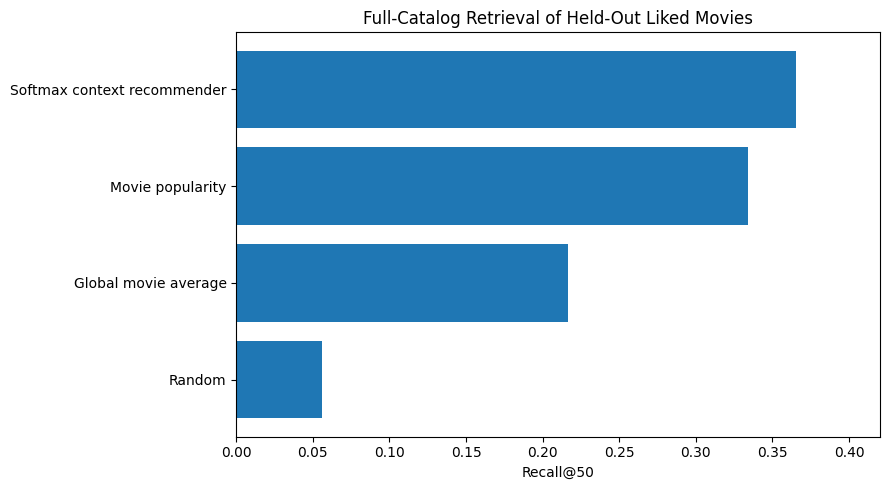

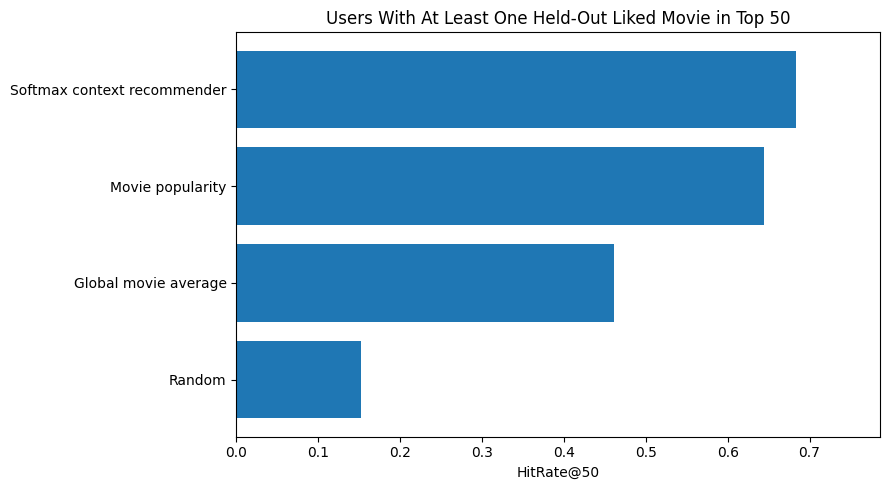

In [25]:
plot_df = validation_summary.sort_values("Recall_at_50", ascending=True)

plt.figure(figsize=(9, 5))
plt.barh(plot_df["Method"], plot_df["Recall_at_50"])
plt.xlabel("Recall@50")
plt.title("Full-Catalog Retrieval of Held-Out Liked Movies")
plt.xlim(0, max(plot_df["Recall_at_50"]) * 1.15)
plt.tight_layout()
plt.show()


plot_df = validation_summary.sort_values("HitRate_at_50", ascending=True)

plt.figure(figsize=(9, 5))
plt.barh(plot_df["Method"], plot_df["HitRate_at_50"])
plt.xlabel("HitRate@50")
plt.title("Users With At Least One Held-Out Liked Movie in Top 50")
plt.xlim(0, max(plot_df["HitRate_at_50"]) * 1.15)
plt.tight_layout()
plt.show()

## 12. Notes for the Article

- SVD embeddings are built from user-mean-centered ratings, so the embedding space captures relative preference patterns rather than raw rating levels.
- The example recommendations use local mean-centered ratings within each context window. A rating is interpreted relative to that specific slice of the user's history.
- Relevance scores are signed before softmax. After softmax, all weights are positive, so below-average movies receive less influence rather than becoming active negative vectors.
- Each candidate movie gets its own context vector. The recommender does not use one fixed user profile for every candidate.
- The validation holds out a small number of liked movies, refits SVD on the remaining training data, and checks whether the model retrieves those held-out liked movies from the full catalog.
- The notebook is designed to demonstrate the linear algebra pipeline: sparse matrices, mean-centering, SVD embeddings, cosine similarity, attention-style weighting, context vectors, and retrieval validation.